
# Airbnb Dataset Cleaning & Preprocessing

## Objective
This notebook cleans and preprocesses the Airbnb NYC 2019 dataset for further analysis and machine learning tasks.


## 1. Import Libraries

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')


## 2. Load Dataset

In [2]:

df = pd.read_csv('AB_NYC_2019.csv')

df.head()


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


## 3. Dataset Overview

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  str    
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  str    
 4   neighbourhood_group             48895 non-null  str    
 5   neighbourhood                   48895 non-null  str    
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  str    
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     38843 non-n

In [4]:
df.describe(include='all')

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,48879,4.889500e+04,48874,48895,48895,48895.000000,48895.000000,48895,48895.000000,48895.000000,48895.000000,38843,38843.000000,48895.000000,48895.000000
unique,NaN,47905,NaN,11452,5,221,NaN,NaN,3,NaN,NaN,NaN,1764,NaN,NaN,NaN
top,NaN,Hillside Hotel,NaN,Michael,Manhattan,Williamsburg,NaN,NaN,Entire home/apt,NaN,NaN,NaN,2019-06-23,NaN,NaN,NaN
freq,NaN,18,NaN,417,21661,3920,NaN,NaN,25409,NaN,NaN,NaN,1413,NaN,NaN,NaN
mean,1.901714e+07,NaN,6.762001e+07,NaN,NaN,NaN,40.728949,-73.952170,NaN,152.720687,7.029962,23.274466,NaN,1.373221,7.143982,112.781327
std,1.098311e+07,NaN,7.861097e+07,NaN,NaN,NaN,0.054530,0.046157,NaN,240.154170,20.510550,44.550582,NaN,1.680442,32.952519,131.622289
min,2.539000e+03,NaN,2.438000e+03,NaN,NaN,NaN,40.499790,-74.244420,NaN,0.000000,1.000000,0.000000,NaN,0.010000,1.000000,0.000000
25%,9.471945e+06,NaN,7.822033e+06,NaN,NaN,NaN,40.690100,-73.983070,NaN,69.000000,1.000000,1.000000,NaN,0.190000,1.000000,0.000000
50%,1.967728e+07,NaN,3.079382e+07,NaN,NaN,NaN,40.723070,-73.955680,NaN,106.000000,3.000000,5.000000,NaN,0.720000,1.000000,45.000000
75%,2.915218e+07,NaN,1.074344e+08,NaN,NaN,NaN,40.763115,-73.936275,NaN,175.000000,5.000000,24.000000,NaN,2.020000,2.000000,227.000000


## 4. Convert Columns to Correct Data Types

In [5]:

df['last_review'] = pd.to_datetime(df['last_review'])

categorical_columns = [
    'neighbourhood_group',
    'neighbourhood',
    'room_type'
]

for col in categorical_columns:
    df[col] = df[col].astype('category')

df.dtypes


id                                         int64
name                                         str
host_id                                    int64
host_name                                    str
neighbourhood_group                     category
neighbourhood                           category
latitude                                 float64
longitude                                float64
room_type                               category
price                                      int64
minimum_nights                             int64
number_of_reviews                          int64
last_review                       datetime64[us]
reviews_per_month                        float64
calculated_host_listings_count             int64
availability_365                           int64
dtype: object

## 5. Check Missing Values

In [6]:
df.isnull().sum()

id                                    0
name                                 16
host_id                               0
host_name                            21
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64


### Observations
- `name` and `host_name` contain a few missing values.
- `last_review` and `reviews_per_month` contain many missing values because some listings have never been reviewed.


## 6. Remove Duplicates

In [7]:

print("Rows before duplicate removal:", len(df))

df = df.drop_duplicates()

print("Rows after duplicate removal:", len(df))


Rows before duplicate removal: 48895
Rows after duplicate removal: 48895


## 7. Handle Missing Values

In [8]:

df['reviews_per_month'] = df['reviews_per_month'].fillna(0)

df['name'] = df['name'].fillna('Unknown')

df['host_name'] = df['host_name'].fillna('Unknown')


## 8. Remove Invalid Prices

In [9]:

print("Rows before removing invalid prices:", len(df))

df = df[df['price'] > 0]

print("Rows after removing invalid prices:", len(df))


Rows before removing invalid prices: 48895
Rows after removing invalid prices: 48884


## 9. Remove Extreme Price Outliers

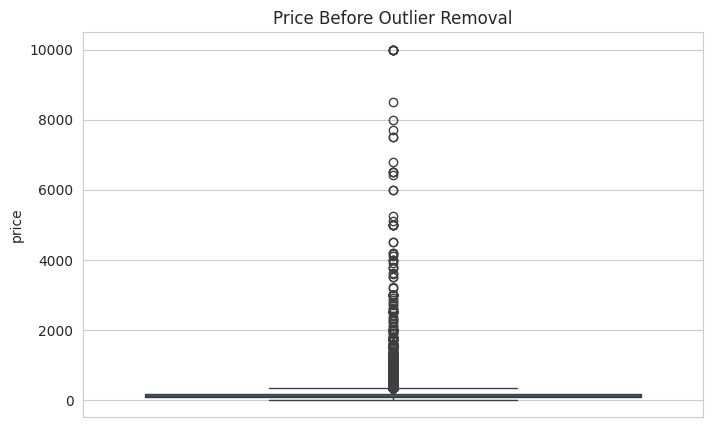

In [10]:

plt.figure(figsize=(8,5))
sns.boxplot(y=df['price'])
plt.title('Price Before Outlier Removal')
plt.show()


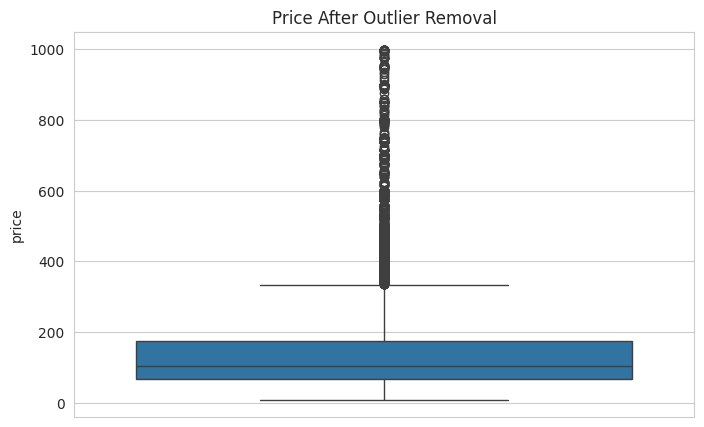

In [11]:

df = df[df['price'] < 1000]

plt.figure(figsize=(8,5))
sns.boxplot(y=df['price'])
plt.title('Price After Outlier Removal')
plt.show()


## 10. Remove Extreme Minimum Nights Outliers

In [12]:

df = df[df['minimum_nights'] <= 365]


## 11. Feature Engineering

In [13]:

df['month'] = df['last_review'].dt.month

def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Autumn'

df['season'] = df['month'].apply(get_season)

df[['last_review', 'month', 'season']].head()


,last_review,month,season
0,2018-10-19,10.0,Autumn
1,2019-05-21,5.0,Spring
2,NaT,NaN,Autumn
3,2019-07-05,7.0,Summer
4,2018-11-19,11.0,Autumn


## 12. Final Dataset Summary

In [14]:
df.info()

<class 'pandas.DataFrame'>
Index: 48572 entries, 0 to 48894
Data columns (total 18 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   id                              48572 non-null  int64         
 1   name                            48572 non-null  str           
 2   host_id                         48572 non-null  int64         
 3   host_name                       48572 non-null  str           
 4   neighbourhood_group             48572 non-null  category      
 5   neighbourhood                   48572 non-null  category      
 6   latitude                        48572 non-null  float64       
 7   longitude                       48572 non-null  float64       
 8   room_type                       48572 non-null  category      
 9   price                           48572 non-null  int64         
 10  minimum_nights                  48572 non-null  int64         
 11  number_of_reviews 

In [15]:
df.describe(include='all')

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,month,season
count,4.857200e+04,48572,4.857200e+04,48572,48572,48572,48572.000000,48572.000000,48572,48572.000000,48572.000000,48572.000000,38690,48572.000000,48572.000000,48572.000000,38690.000000,48572
unique,NaN,47591,NaN,11403,5,221,NaN,NaN,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4
top,NaN,Hillside Hotel,NaN,Michael,Manhattan,Williamsburg,NaN,NaN,Entire home/apt,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Summer
freq,NaN,18,NaN,415,21441,3905,NaN,NaN,25155,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,21136
mean,1.902306e+07,NaN,6.764521e+07,NaN,NaN,NaN,40.728927,-73.952028,NaN,140.269826,6.784176,23.378016,2018-10-04 15:19:20.672008,1.095586,7.170345,112.314440,6.174464,NaN
min,2.539000e+03,NaN,2.438000e+03,NaN,NaN,NaN,40.499790,-74.244420,NaN,10.000000,1.000000,0.000000,2011-03-28 00:00:00,0.000000,1.000000,0.000000,1.000000,NaN
25%,9.476845e+06,NaN,7.831209e+06,NaN,NaN,NaN,40.690000,-73.982950,NaN,69.000000,1.000000,1.000000,2018-07-10 00:00:00,0.040000,1.000000,0.000000,5.000000,NaN
50%,1.967743e+07,NaN,3.085513e+07,NaN,NaN,NaN,40.722960,-73.955580,NaN,105.000000,3.000000,5.000000,2019-05-19 00:00:00,0.380000,1.000000,44.000000,6.000000,NaN
75%,2.914961e+07,NaN,1.074344e+08,NaN,NaN,NaN,40.763130,-73.936100,NaN,175.000000,5.000000,24.000000,2019-06-23 00:00:00,1.600000,2.000000,225.000000,7.000000,NaN
max,3.648724e+07,NaN,2.743213e+08,NaN,NaN,NaN,40.913060,-73.712990,NaN,999.000000,365.000000,629.000000,2019-07-08 00:00:00,58.500000,327.000000,365.000000,12.000000,NaN


## 13. Save Cleaned Dataset

In [16]:

df.to_csv('airbnb_cleaned.csv', index=False)

print("Cleaned dataset saved as airbnb_cleaned.csv")


Cleaned dataset saved as airbnb_cleaned.csv



# Conclusion

The dataset has been cleaned and prepared for:
- Exploratory Data Analysis (EDA)
- Machine learning
- Anomaly detection
- Neural Architecture Search (NAS)

The cleaned dataset was saved as `airbnb_cleaned.csv`.
